# STEP 1 — Import Required Libraries 📚

In [3]:
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# STEP 2 — Load Dataset 📂

In [5]:
# Load CSV File

df = pd.read_csv("DTREE_WA_Fn-UseC_-Telco-Customer-Churn.csv")

# print(df.head())
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# STEP 3 — Basic Dataset Information 🔍

In [6]:
# Shape of Dataset
print("Dataset shape :")
print(df.shape)

Dataset shape :
(7043, 21)


In [7]:
# Column Names
print("Column Names :")
print(df.columns)

Column Names :
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [8]:
# Dataset Information
print("Dataset Info :")
print(df.info())

Dataset Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

In [10]:
# Statistical Summary
print("Statistical Summary :")
print(df.describe())

Stastical Summary :
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


# STEP 4 — Check Missing Values 🚨

In [11]:
print("Missing Values :")
print(df.isnull().sum())

Missing Values :
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# STEP 5 — Check Duplicate Rows 🔁

In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# STEP 6 — Remove CustomerID Column ❌

In [14]:
# customerID has unique values
# It does not help prediction

if 'custmerID' in df.columns:
    df.drop('customerID', axis = 1, inplace = True)
    
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

# STEP 7 — Handle TotalCharges Column ⚡

In [15]:
# Convert TotalCharges into numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

# Fill Missing Values with Mean

df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace = True)

print(df['TotalCharges'].dtype)

float64


# STEP 8 — Check Target Variable 🎯

In [16]:
print(df['Churn'].value_counts())

No     5174
Yes    1869
Name: Churn, dtype: int64


# STEP 9 — Target Variable Visualization 📊

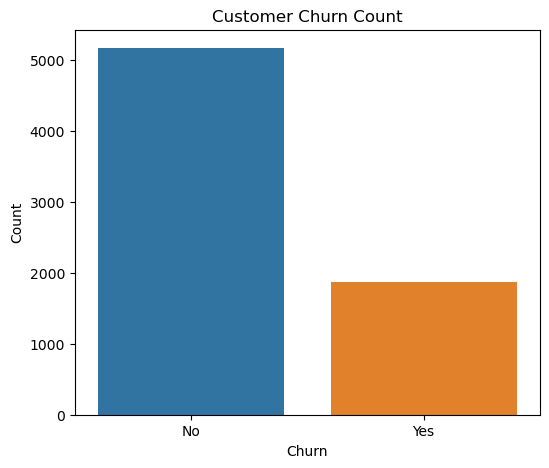

In [17]:
plt.figure(figsize = (6,5))

sns.countplot(x = 'Churn', data = df)

plt.title('Customer Churn Count')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

# STEP 10 — Encode Categorical Columns 🔥

In [18]:
# Create Label Encoder
le = LabelEncoder()

# Convert all object columns
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])
        
print(df.head())

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0        5375       0              0        1           0       1   
1        3962       1              0        0           0      34   
2        2564       1              0        0           0       2   
3        5535       1              0        0           0      45   
4        6511       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   


# STEP 11 — Correlation Heatmap 🌡️

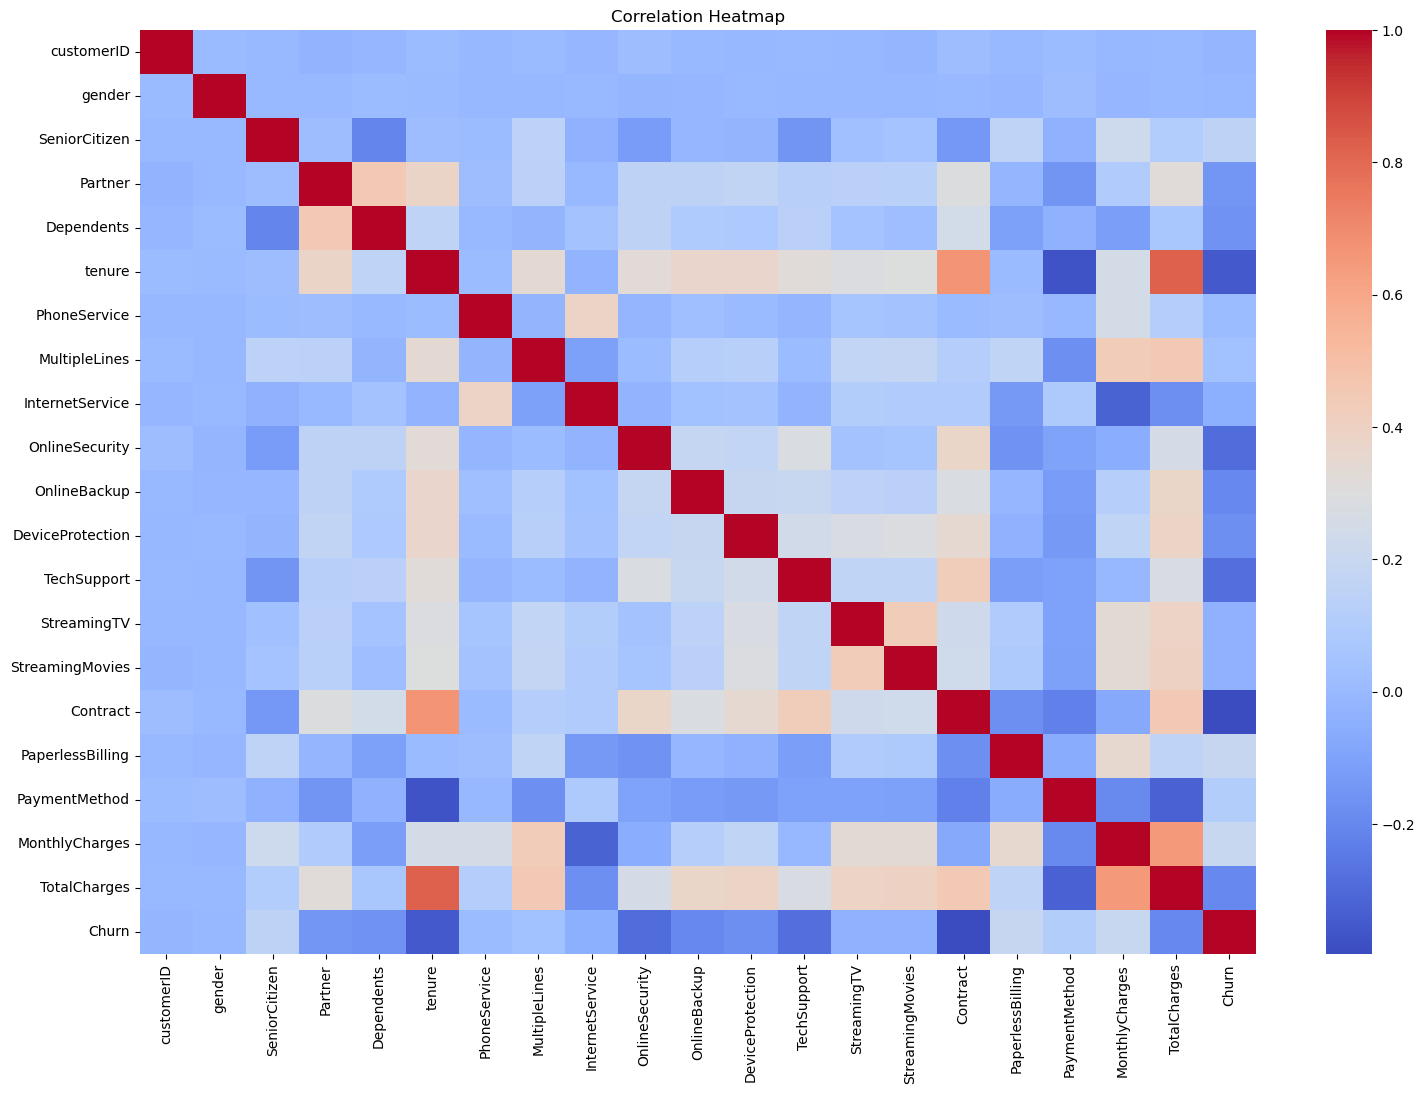

In [19]:
plt.figure(figsize = (18,12))

sns.heatmap(df.corr(), annot = False, cmap = 'coolwarm')

plt.title('Correlation Heatmap')

plt.show()

# STEP 12 — Define Features and Target 🎯

In [20]:
# Features
X = df.drop('Churn', axis = 1)

# Target
y = df['Churn']

print(X.head())
print(y.head())

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0        5375       0              0        1           0       1   
1        3962       1              0        0           0      34   
2        2564       1              0        0           0       2   
3        5535       1              0        0           0      45   
4        6511       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0             0              1                0               0             2   
1             1              0                0               2             0   
2             1              0                0               2             2   
3             0              1                0               2             0   
4             1              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0   

# STEP 13 — Train Test Split ✂️

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

# STEP 14 — Build Decision Tree Model 🌳

In [26]:
model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 5,
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 42
)

# Train Model
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

# STEP 15 — Model Prediction 🔮

In [27]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 0 ... 0 0 0]


# STEP 16 — Accuracy Score 📈

In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.7842441447835344


# STEP 17 — Confusion Matrix 🔥

In [29]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[897 138]
 [166 208]]


# STEP 18 — Confusion Matrix Graph 📊

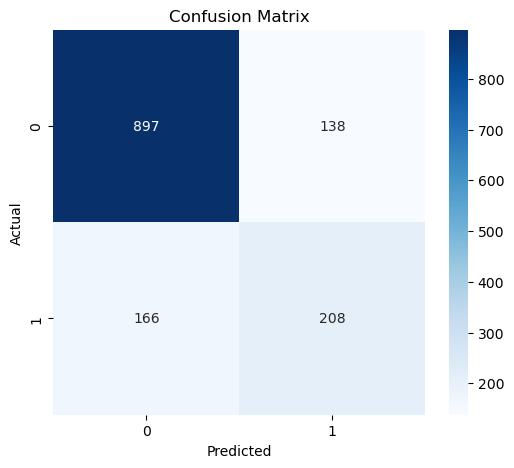

In [32]:
plt.figure(figsize = (6,5))

sns.heatmap(cm, annot = True, fmt = 'd', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# STEP 19 — Classification Report 📄

In [33]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.60      0.56      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



# STEP 20 — Decision Tree Visualization 🌳

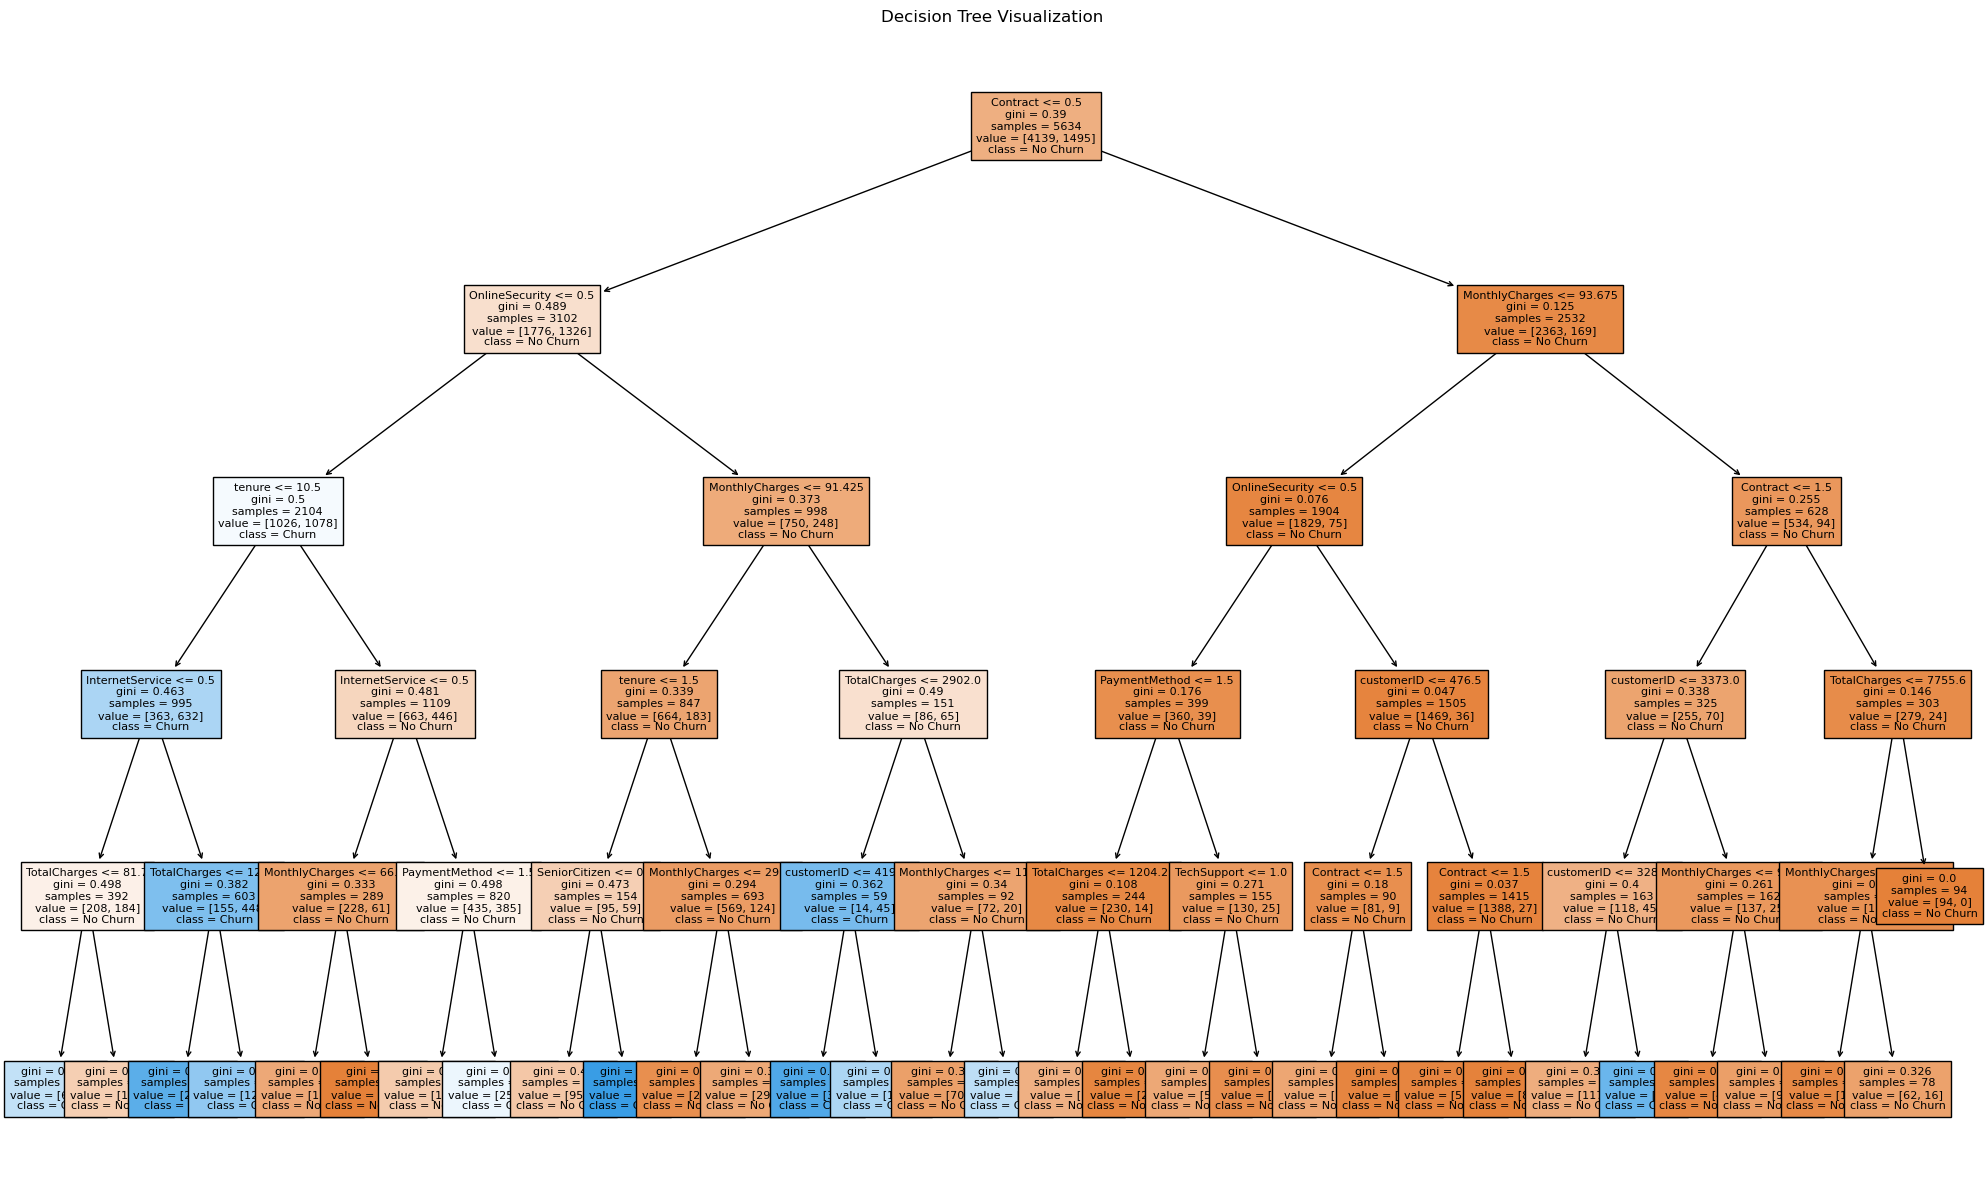

In [34]:
plt.figure(figsize = (25,15))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = ['No Churn', 'Churn'],
    filled = True,
    fontsize = 8
)

plt.title("Decision Tree Visualization")

plt.show()

# STEP 21 — Feature Importance 🔥

In [36]:
importance = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : model.feature_importances_
})

importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

print(importance)

             Feature  Importance
15          Contract    0.526218
9     OnlineSecurity    0.138777
5             tenure    0.095823
8    InternetService    0.091058
19      TotalCharges    0.057489
18    MonthlyCharges    0.054125
17     PaymentMethod    0.015701
0         customerID    0.011921
2      SeniorCitizen    0.006750
12       TechSupport    0.002138
7      MultipleLines    0.000000
6       PhoneService    0.000000
1             gender    0.000000
11  DeviceProtection    0.000000
13       StreamingTV    0.000000
14   StreamingMovies    0.000000
4         Dependents    0.000000
16  PaperlessBilling    0.000000
3            Partner    0.000000
10      OnlineBackup    0.000000


# STEP 22 — Feature Importance Graph 📊

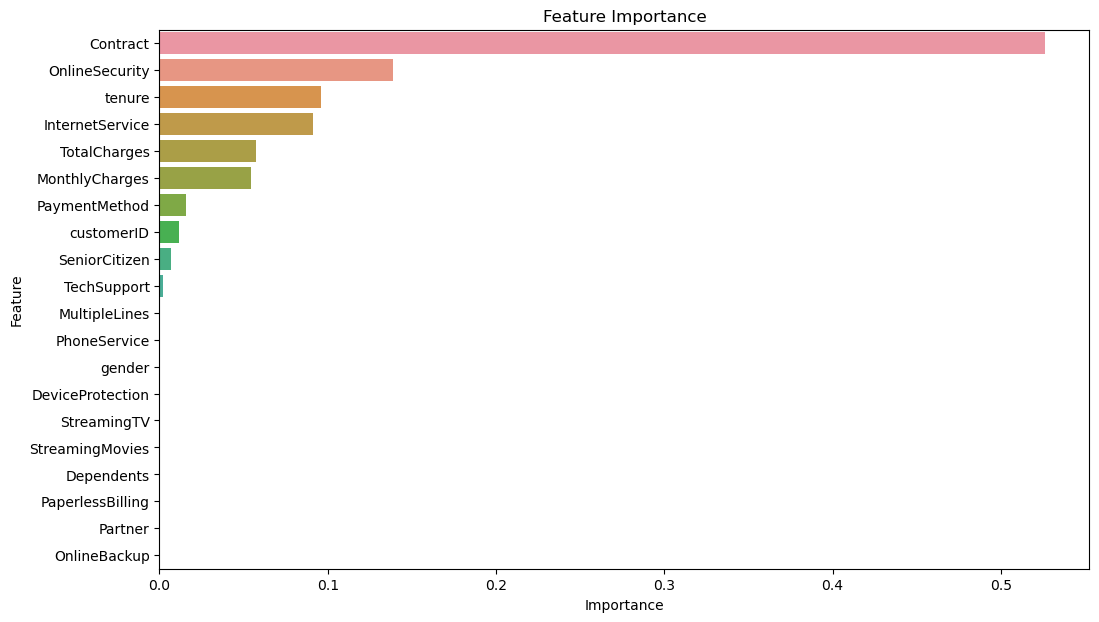

In [38]:
plt.figure(figsize = (12,7))

sns.barplot(
    x = 'Importance',
    y = 'Feature',
    data = importance 
)

plt.title("Feature Importance")

plt.show()

# STEP 23 — Hyperparameter Tuning ⚙️

In [40]:
params = {
    'max_depth' : [2,3,4,5,6,7],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,5,10],
    'criterion' : ['gini','entropy']
}

grid = GridSearchCV(
    estimator = DecisionTreeClassifier(random_state = 42),
    param_grid = params,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

# STEP 24 — Best Parameters 🏆

In [42]:
print('Best Parameters :')
print(grid.best_params_)

Best Parameters :
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


# STEP 25 — Best Model 🔥

In [43]:
best_model = grid.best_estimator_

print(best_model)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, random_state=42)


# STEP 26 — Prediction Using Best Model 🔮

In [45]:
best_pred = best_model.predict(X_test)
best_pred

array([0, 1, 0, ..., 0, 0, 0])

# STEP 27 — Best Model Accuracy 📈

In [47]:
best_accuracy = accuracy_score(y_test, best_pred)

print("Best Accuracy :", best_accuracy)

Best Accuracy : 0.7849538679914834


# STEP 28 — Train Accuracy vs Test Accuracy 🔥

In [48]:
train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)

print("Train Accuracy :", train_score)
print("Test Accuracy :", test_score)

Train Accuracy : 0.8044018459353922
Test Accuracy : 0.7849538679914834


# STEP 29 — Final Confusion Matrix 📊

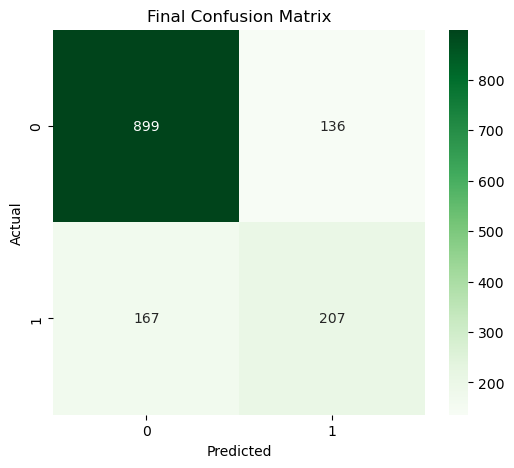

In [49]:
final_cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize = (6,5))

sns.heatmap(final_cm, annot = True, fmt = 'd', cmap = 'Greens')

plt.title('Final Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# STEP 30 — Final Classification Report 📄

In [50]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.60      0.55      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



# STEP 31 — Final Decision Tree Graph 🌳

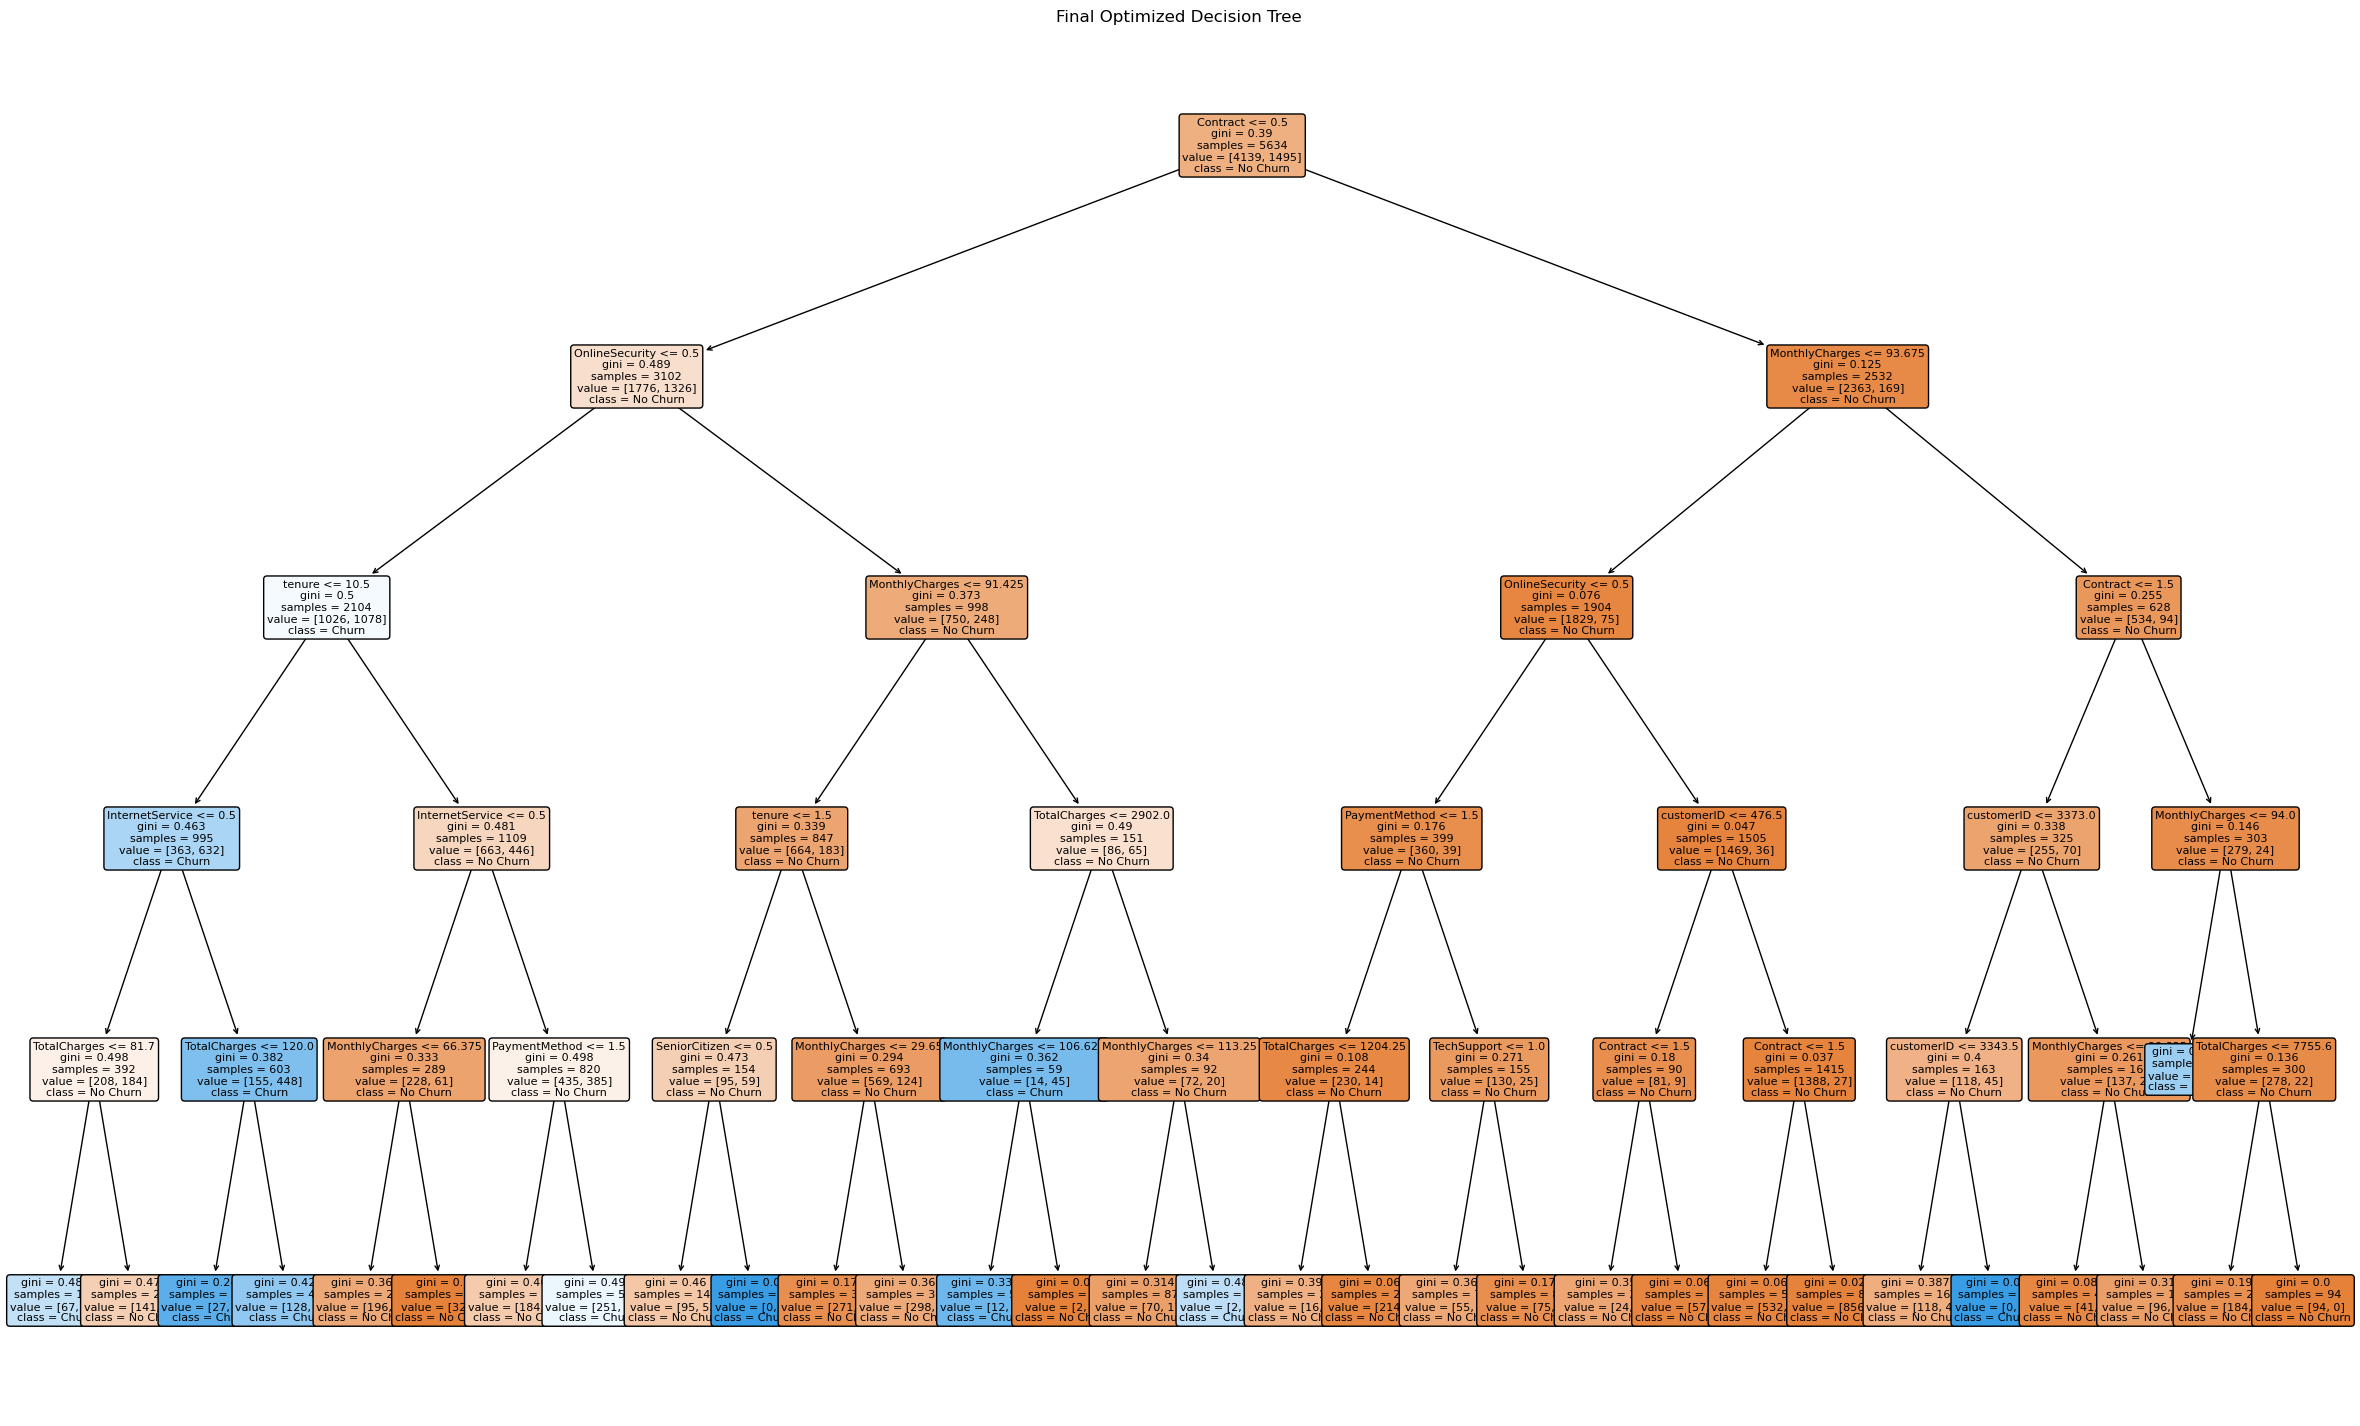

In [52]:
plt.figure(figsize = (30,18))

plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ['No Churn', 'Churn'],
    filled = True,
    rounded = True,
    fontsize = 8
)

plt.title('Final Optimized Decision Tree')

plt.show()

# STEP 32 — Predict New Customer 🔮

In [ ]:
IMPORTANT:

Input values must follow:
    
    Same column order as dataset

In [54]:
sample = X.iloc[0:1]

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Customer will Churn")
else:
    print("Customer will not Churn")

Customer will Churn


# STEP 33 — Model Saving 💾

In [55]:
import pickle

with open('Telco_DecisionTree_Model.pkl', 'wb') as file:
    pickle.dump(best_model, file)
    
print("Model Saved Successfully")

Model Saved Successfully
